# Chapter 7 — Overfitting and Regularization

**Goals**

- See overfitting in action by fitting polynomials of increasing degree to a small noisy dataset.
- Watch train loss keep dropping while validation loss U-turns.
- Tame it with **L2 (Ridge)** and **L1 (Lasso)** regularization.
- Read a learning curve.

Pair with `docs/03_regression.md`, Part B.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. The dataset — a noisy sine wave

Hidden truth: $y = \sin(2\pi x) + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 0.2^2)$. Twenty samples, $x \in [0, 1]$. A linear model in $x$ alone (degree 1) cannot capture a sine; high-degree polynomials *can*, but they will memorize the noise.

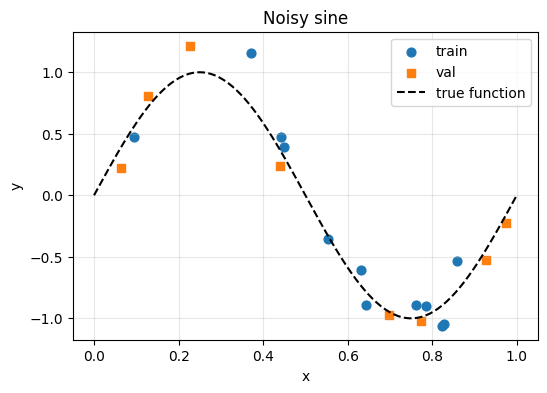

In [2]:
def true_fn(x):
    return np.sin(2 * np.pi * x)

N = 20
x_all = rng.uniform(0, 1, size=N)
y_all = true_fn(x_all) + rng.normal(0, 0.2, size=N)

x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all, test_size=0.4, random_state=SEED
)

xs_fine = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_train, y_train, color='tab:blue', label='train', s=40)
ax.scatter(x_val,   y_val,   color='tab:orange', label='val',   s=40, marker='s')
ax.plot(xs_fine, true_fn(xs_fine), color='black', ls='--', label='true function')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Noisy sine')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 3. Fit polynomials of degree 1, 3, 9

We fit $\hat{y} = w_0 + w_1 x + w_2 x^2 + \dots + w_p x^p$ for $p \in \{1, 3, 9\}$ and compare on train vs val.

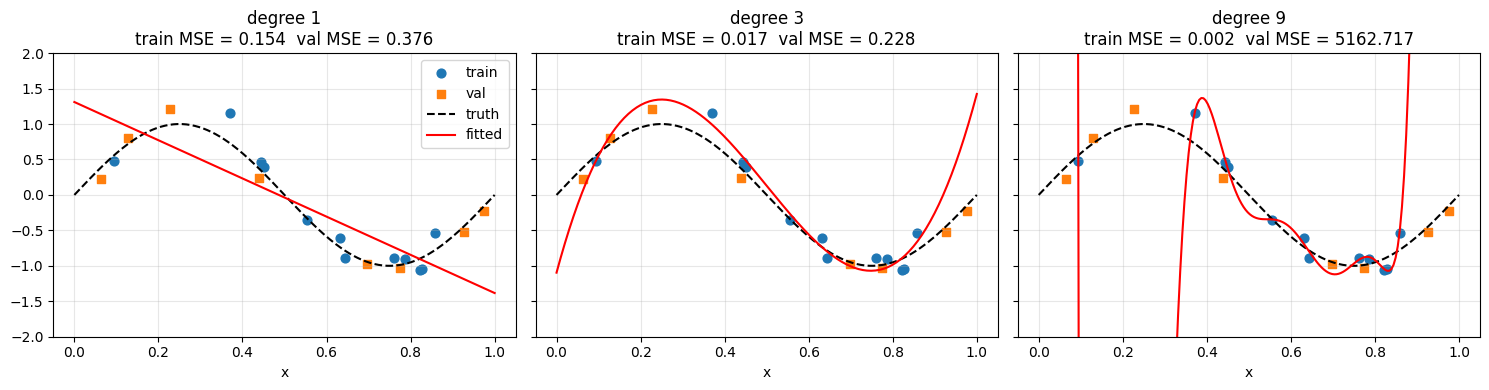

In [3]:
def fit_poly(degree):
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                         StandardScaler(),
                         LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)
    return model

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, degree in zip(axes, [1, 3, 9]):
    model = fit_poly(degree)
    y_train_pred = model.predict(x_train.reshape(-1, 1))
    y_val_pred   = model.predict(x_val.reshape(-1, 1))
    y_fine_pred  = model.predict(xs_fine.reshape(-1, 1))
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse   = mean_squared_error(y_val,   y_val_pred)
    ax.scatter(x_train, y_train, color='tab:blue', label='train', s=40)
    ax.scatter(x_val,   y_val,   color='tab:orange', label='val',   s=40, marker='s')
    ax.plot(xs_fine, true_fn(xs_fine), color='black', ls='--', label='truth')
    ax.plot(xs_fine, y_fine_pred,      color='red',    label='fitted')
    ax.set_title(f'degree {degree}\ntrain MSE = {train_mse:.3f}  val MSE = {val_mse:.3f}')
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x'); ax.grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

**What you should see:**

- Degree 1 → underfit. Both losses high.
- Degree 3 → good fit. Both losses small; the curve tracks the truth.
- Degree 9 → overfit. Train loss tiny, val loss huge; the curve oscillates wildly between training points.

## 4. Sweep degree and plot train vs val MSE

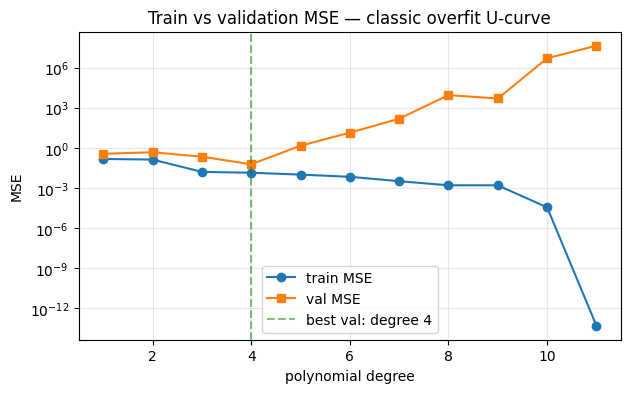

In [4]:
degrees = list(range(1, 12))
train_mses, val_mses = [], []
for d in degrees:
    model = fit_poly(d)
    train_mses.append(mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1))))
    val_mses.append(  mean_squared_error(y_val,   model.predict(x_val.reshape(-1, 1))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degrees, train_mses, marker='o', label='train MSE')
ax.plot(degrees, val_mses,   marker='s', label='val MSE')
best_d = degrees[int(np.argmin(val_mses))]
ax.axvline(best_d, color='green', ls='--', alpha=0.5, label=f'best val: degree {best_d}')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('MSE')
ax.set_title('Train vs validation MSE — classic overfit U-curve')
ax.set_yscale('log')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 5. Regularize the degree-9 model

Degree 9 was overfitting. With Ridge or Lasso regularization we can keep the same model class but shrink the weights so the curve becomes smooth again.

/home/bangbc/miniforge3/envs/aicourse/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.304e-02, tolerance: 6.127e-04
  model = cd_fast.enet_coordinate_descent(


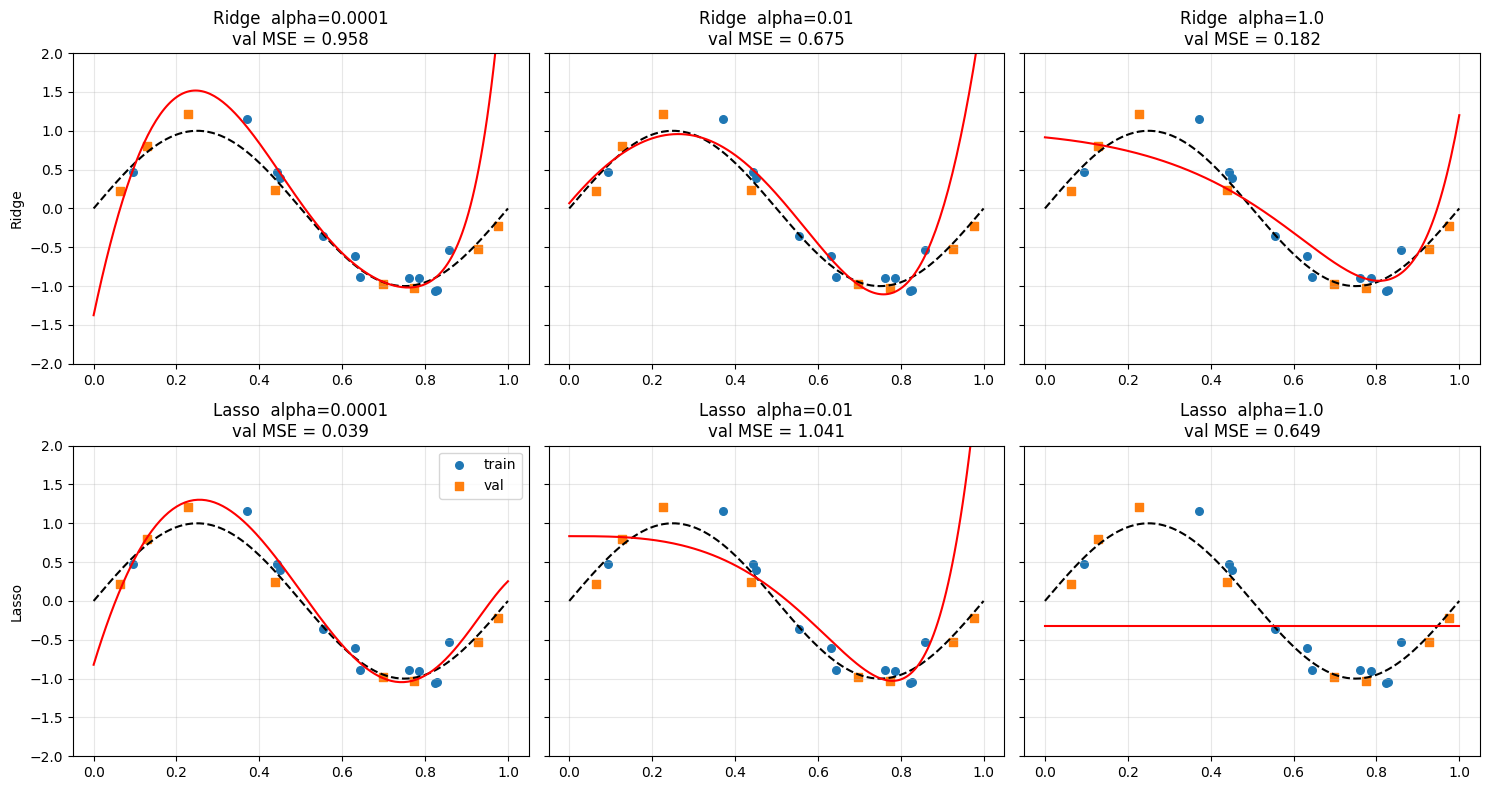

In [5]:
def fit_regularized(model_cls, alpha, degree=9):
    model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                         StandardScaler(),
                         model_cls(alpha=alpha, max_iter=20000))
    model.fit(x_train.reshape(-1, 1), y_train)
    return model

alphas = [0.0001, 0.01, 1.0]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for col, alpha in enumerate(alphas):
    for row, model_cls in enumerate([Ridge, Lasso]):
        ax = axes[row, col]
        model = fit_regularized(model_cls, alpha=alpha)
        y_fine_pred = model.predict(xs_fine.reshape(-1, 1))
        val_mse = mean_squared_error(y_val, model.predict(x_val.reshape(-1, 1)))
        ax.scatter(x_train, y_train, color='tab:blue', s=30, label='train')
        ax.scatter(x_val,   y_val,   color='tab:orange', s=30, marker='s', label='val')
        ax.plot(xs_fine, true_fn(xs_fine), color='black', ls='--')
        ax.plot(xs_fine, y_fine_pred, color='red')
        ax.set_title(f'{model_cls.__name__}  alpha={alpha}\nval MSE = {val_mse:.3f}')
        ax.set_ylim(-2, 2)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(model_cls.__name__)
axes[1, 0].legend()
plt.tight_layout()
plt.show()

Increasing alpha shrinks the wiggle. Too much regularization (right column) underfits — the curve flattens toward the mean.

Lasso also drives many polynomial coefficients to exactly zero. Inspect:

In [6]:
lasso = fit_regularized(Lasso, alpha=0.01).named_steps['lasso']
ridge = fit_regularized(Ridge, alpha=0.01).named_steps['ridge']
coefs = pd.DataFrame({'ridge': ridge.coef_, 'lasso': lasso.coef_})
coefs.index.name = 'poly term'
coefs.round(4)

,ridge,lasso
poly term,,
0,1.3993,0.0000
1,-2.1589,-0.0000
2,-1.6020,-1.2752
3,-0.2823,-0.0000
4,0.6421,-0.0000
5,0.9648,0.0000
6,0.7822,0.0000
7,0.2554,0.0000
8,-0.4674,0.7468


## 6. Learning curve — does more data help?

Use scikit-learn's `learning_curve` to plot train and CV losses as the training-set size grows.

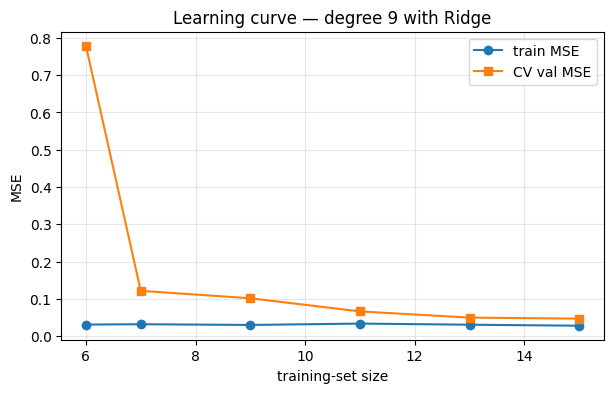

In [7]:
X_all = x_all.reshape(-1, 1)
y_all_arr = y_all

model_for_curve = make_pipeline(
    PolynomialFeatures(degree=9, include_bias=False),
    StandardScaler(),
    Ridge(alpha=0.01),
)
train_sizes_abs, train_scores, val_scores = learning_curve(
    model_for_curve, X_all, y_all_arr,
    train_sizes=np.linspace(0.4, 1.0, 6),
    cv=4, scoring='neg_mean_squared_error', random_state=SEED,
)
train_mse = -train_scores.mean(axis=1)
val_mse   = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes_abs, train_mse, marker='o', label='train MSE')
ax.plot(train_sizes_abs, val_mse,   marker='s', label='CV val MSE')
ax.set_xlabel('training-set size'); ax.set_ylabel('MSE')
ax.set_title('Learning curve — degree 9 with Ridge')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 7. Summary

- Model capacity is a knob. Too low → underfit. Too high → overfit.
- Train loss alone is misleading; you need validation loss to choose model capacity.
- Regularization (L1, L2) lets you keep a flexible model class while shrinking the effective capacity.
- Learning curves diagnose whether you need more data or a different model.

**Next:** `labs/lab_04_model_selection.ipynb` — pick the regularization strength with K-fold CV like a pro.

## Quick Check

1. How do train loss and validation loss behave when a model overfits?
2. Define bias-variance tradeoff in two short sentences.
3. What is the practical difference between Ridge (L2) and Lasso (L1)?
4. Why is K-fold cross-validation preferred over a single train/val split?
5. When would you reach for early stopping instead of explicit regularization?


## Further Reading

- Vũ Hữu Tiệp, *Machine Learning cơ bản* — Chương 8 (Overfitting và Regularization).
- Hastie, Tibshirani, Friedman, *The Elements of Statistical Learning*, Chapter 7.
- scikit-learn user guide: *Model evaluation* and *Tuning hyperparameters*.
